In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

%matplotlib inline
print("Libraries Loaded ✅")

Libraries Loaded ✅


In [2]:
import zipfile
import os
zip_path = '/Users/namburunainavismi/Downloads/sentiment140 dataset.zip'
extract_path = '/Users/namburunainavismi/Downloads/sentiment140'
os.makedirs(extract_path, exist_ok=True)

with zipfile.ZipFile(zip_path, 'r')as z:
    z.extractall(extract_path)
    print("Files inside Zip: ")
    for f in z.namelist():
        print("->",f)

Files inside Zip: 
-> Exploring Data.ipynb
-> test_data.csv
-> train_data.csv
-> vocab.json
-> vocab.py


In [4]:
temp = pd.read_csv('/Users/namburunainavismi/Downloads/sentiment140/train_data.csv', nrows=5)
print("Columns: ", temp.columns.tolist())
print("Shape Preview: ", temp.shape)
print(temp.head())

Columns:  ['sentence', 'sentiment']
Shape Preview:  (5, 2)
                                            sentence  sentiment
0  awww that s a bummer you shoulda got david car...          0
1  is upset that he can t update his facebook by ...          0
2  i dived many times for the ball managed to sav...          0
3     my whole body feels itchy and like its on fire          0
4  no it s not behaving at all i m mad why am i h...          0


In [5]:
df = pd.read_csv('/Users/namburunainavismi/Downloads/sentiment140/train_data.csv')

print("Shape: ", df.shape)
print("\nColumn names: ", df.columns.tolist())
print("\nSentiment unique values: ", df['sentiment'].unique())
print("Sentiment Distribution: ")
print(df['sentiment'].value_counts())
print("\nMissing Values: ")
print(df.isnull().sum())
print("\nSample Tweets: ")
print(df['sentence'].head(10).to_string())

Shape:  (1523975, 2)

Column names:  ['sentence', 'sentiment']

Sentiment unique values:  [0 1]
Sentiment Distribution: 
0    767059
1    756916
Name: sentiment, dtype: int64

Missing Values: 
sentence     0
sentiment    0
dtype: int64

Sample Tweets: 
0    awww that s a bummer you shoulda got david car...
1    is upset that he can t update his facebook by ...
2    i dived many times for the ball managed to sav...
3       my whole body feels itchy and like its on fire
4    no it s not behaving at all i m mad why am i h...
5                                   not the whole crew
6                                           need a hug
7    hey long time no see yes rains a bit only a bi...
8                             nope they didn t have it
9                                         que me muera


In [10]:
from sklearn.model_selection import train_test_split
df_sample, _ = train_test_split(
    df,
    train_size=200000,
    random_state=42,
    stratify=df['sentiment']
)
print("Sample Shape: ", df_sample.shape)
print("Sentiment Distribution in Sample: ")
print(df_sample['sentiment'].value_counts())
print("\nBalence check should be ~50%: ")
print(df_sample['sentiment'].value_counts(normalize=True).round(3))

Sample Shape:  (200000, 2)
Sentiment Distribution in Sample: 
0    100666
1     99334
Name: sentiment, dtype: int64

Balence check should be ~50%: 
0    0.503
1    0.497
Name: sentiment, dtype: float64


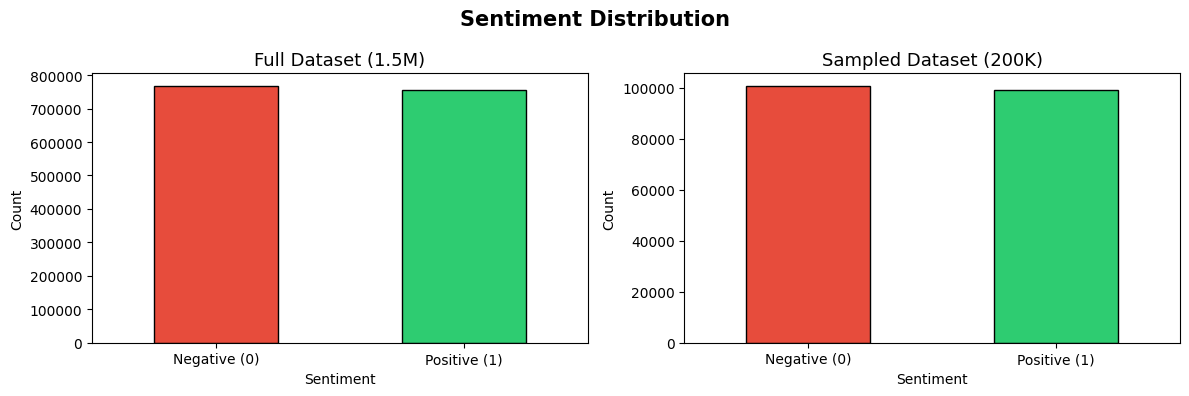

In [11]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Full dataset
df['sentiment'].value_counts().plot(
    kind='bar',
    ax=axes[0],
    color=['#e74c3c', '#2ecc71'],
    edgecolor='black'
)
axes[0].set_title('Full Dataset (1.5M)', fontsize=13)
axes[0].set_xlabel('Sentiment')
axes[0].set_ylabel('Count')
axes[0].set_xticklabels(['Negative (0)', 'Positive (1)'], rotation=0)

# Sampled dataset
df_sample['sentiment'].value_counts().plot(
    kind='bar',
    ax=axes[1],
    color=['#e74c3c', '#2ecc71'],
    edgecolor='black'
)
axes[1].set_title('Sampled Dataset (200K)', fontsize=13)
axes[1].set_xlabel('Sentiment')
axes[1].set_ylabel('Count')
axes[1].set_xticklabels(['Negative (0)', 'Positive (1)'], rotation=0)

plt.suptitle('Sentiment Distribution', fontsize=15, fontweight='bold')
plt.tight_layout()
plt.show()

In [12]:
import nltk
import re
import string

nltk.download('stopwords')
from nltk.corpus import stopwords

stop_words=set(stopwords.words('english'))
print(f"Total Stopwords:{len(stop_words)} ")
print("Sample Stopwords: ", list(stop_words)[:10])

[nltk_data] Downloading package stopwords to
[nltk_data]     /Users/namburunainavismi/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.


Total Stopwords:198 
Sample Stopwords:  ["aren't", 'will', 'myself', "it'd", 'them', "hasn't", "that'll", 'itself', "they'd", 'what']


In [13]:
def clean_text(text):
    text = text.lower()
    text = re.sub(r'\d+', '', text)
    text = text.translate(str.maketrans('', '', string.punctuation))
    words = text.split()
    words = [w for w in words if w not in stop_words]
    words = [w for w in words if len(w) > 2]
    
    text = ' '.join(words)
    text = text.strip()
    return text

test_tweets = [
    "I LOVE this product!! It's amazing 100%",
    "que me muera",
    "is upset that he can t update his facebook by texting it",
    "need a hug"
]

print("Test Cleaning Function:\n")
for tweet in test_tweets:
    print(f"  Original : {tweet}")
    print(f"  Cleaned  : {clean_text(tweet)}")
    print()

Test Cleaning Function:

  Original : I LOVE this product!! It's amazing 100%
  Cleaned  : love product amazing

  Original : que me muera
  Cleaned  : que muera

  Original : is upset that he can t update his facebook by texting it
  Cleaned  : upset update facebook texting

  Original : need a hug
  Cleaned  : need hug



In [15]:
df_sample['cleaned'] = df_sample['sentence'].apply(clean_text)
empty_mask = df_sample['cleaned'].str.strip() == ''
print(f"Tweets that became empty after cleaning: {empty_mask.sum()}")
print(f"Percentage: {(empty_mask.sum() / len(df_sample) * 100):.2f}%")

print("\nExamples of tweets that became empty:")
print(df_sample[empty_mask]['sentence'].head(10).to_string())

df_clean = df_sample[~empty_mask].reset_index(drop=True)
print(f"\nDataset size before: {len(df_sample)}")
print(f"Dataset size after : {len(df_clean)}")

Tweets that became empty after cleaning: 384
Percentage: 0.19%

Examples of tweets that became empty:
229412                                 i m not bv
243108                                      oh bb
1104373                              no you can t
1324151                   am ok ta what you up to
520318                                     you do
895604                                  what what
1348905                               as are you 
1060626                                         k
1157894                                          
46805                                 i only have

Dataset size before: 200000
Dataset size after : 199616


In [16]:
from sklearn.model_selection import train_test_split

X = df_clean['cleaned']
Y = df_clean['sentiment']

X_train, X_test, Y_train, Y_test = train_test_split(
    X, Y,
    test_size = 0.2,
    random_state = 42,
    stratify = Y
)

print(f"Training Samples: {len(X_train)}")
print(f"Testing Samples: {len(X_test)}")
print(f"\nTrain Sentiment Balence: ")
print(Y_train.value_counts(normalize=True).round(3))
print(f"\nTest Sentiment Balence: ")
print(Y_test.value_counts(normalize=True).round(3))

Training Samples: 159692
Testing Samples: 39924

Train Sentiment Balence: 
0    0.503
1    0.497
Name: sentiment, dtype: float64

Test Sentiment Balence: 
0    0.503
1    0.497
Name: sentiment, dtype: float64


In [20]:
from sklearn.feature_extraction.text import TfidfVectorizer

vectorizer = TfidfVectorizer(
max_features = 50000,
ngram_range = (1, 2),
min_df = 2
)

X_train_tfidf = vectorizer.fit_transform(X_train)
X_test_tfidf = vectorizer.transform(X_test)

print(f"Vocabulary Size: {len(vectorizer.vocabulary_)}")
print(f"X_train TF-IDF Shape: {X_train_tfidf.shape}")
print(f"X_test TF-IDF Shape: {X_test_tfidf.shape}")

Vocabulary Size: 50000
X_train TF-IDF Shape: (159692, 50000)
X_test TF-IDF Shape: (39924, 50000)


In [23]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report

model = LogisticRegression(
max_iter = 1000,
random_state = 42,
n_jobs = -1
)

print("Traning Model...")
model.fit(X_train_tfidf, Y_train)
print("Training Completed..")

Y_pred = model.predict(X_test_tfidf)

print(f"\nAccuracy Score: {accuracy_score(Y_test, Y_pred):.4f}")
print("\nClassification Report: ")
print(classification_report(Y_test, Y_pred, target_names=['Negative', 'Positive']))

Traning Model...
Training Completed..

Accuracy Score: 0.7680

Classification Report: 
              precision    recall  f1-score   support

    Negative       0.78      0.75      0.77     20099
    Positive       0.76      0.78      0.77     19825

    accuracy                           0.77     39924
   macro avg       0.77      0.77      0.77     39924
weighted avg       0.77      0.77      0.77     39924



In [24]:
def predict_sentiment(text, vectorizer, model):

    cleaned = clean_text(text)
    print(f"Cleaned text: '{cleaned}'")
    
    vectorized = vectorizer.transform([cleaned])
    
    prediction = model.predict(vectorized)[0]
    probability = model.predict_proba(vectorized)[0]
    
    sentiment = "Positive 😊" if prediction == 1 else "Negative 😞"
    confidence = probability[prediction]
    
    return sentiment, confidence

test_sentences = [
    "I absolutely love this new phone, it's incredible",
    "This is the worst experience I have ever had",
    "The weather is okay today",
    "I am so happy and grateful for everything",
    "I hate waiting in long queues"
]

print("Manual Prediction Test\n" + "="*40)
for sentence in test_sentences:
    sentiment, confidence = predict_sentiment(sentence, vectorizer, model)
    print(f"\nInput     : {sentence}")
    print(f"Sentiment : {sentiment}")
    print(f"Confidence: {confidence:.2%}")
    print("-"*40)

Manual Prediction Test
Cleaned text: 'absolutely love new phone incredible'

Input     : I absolutely love this new phone, it's incredible
Sentiment : Positive 😊
Confidence: 90.57%
----------------------------------------
Cleaned text: 'worst experience ever'

Input     : This is the worst experience I have ever had
Sentiment : Negative 😞
Confidence: 77.74%
----------------------------------------
Cleaned text: 'weather okay today'

Input     : The weather is okay today
Sentiment : Negative 😞
Confidence: 55.88%
----------------------------------------
Cleaned text: 'happy grateful everything'

Input     : I am so happy and grateful for everything
Sentiment : Positive 😊
Confidence: 92.33%
----------------------------------------
Cleaned text: 'hate waiting long queues'

Input     : I hate waiting in long queues
Sentiment : Negative 😞
Confidence: 84.37%
----------------------------------------


In [26]:
import joblib
import os

os.makedirs('saved_model', exist_ok=True)

joblib.dump(vectorizer, 'saved_model/tfidf_vectorizer.pkl')
print("Vectorizer saved -> saved_model/tfidf_vectorizer.pkl")

joblib.dump(model, 'saved_model/sentiment_model.pkl')
print("Model saved -> saved_model/sentiment_model.pkl")

utils_code = '''
import re
import string
from nltk.corpus import stopwords
import nltk

nltk.download('stopwords', quiet=True)
stop_words = set(stopwords.words('english'))

def clean_text(text):
    text = text.lower()
    text = re.sub(r'\\d+', '', text)
    text = text.translate(str.maketrans('', '', string.punctuation))
    words = text.split()
    words = [w for w in words if w not in stop_words]
    words = [w for w in words if len(w) > 2]
    text = ' '.join(words)
    text = text.strip()
    return text
'''

with open('saved_model/utils.py', 'w') as f:
    f.write(utils_code)
print("Utils saved -> saved_model/utils.py")

# Verify all files exist
print("\nFiles in saved_model/:")
for f in os.listdir('saved_model'):
    size = os.path.getsize(f'saved_model/{f}') / (1024*1024)
    print(f"  {f} -> {size:.2f} MB")

Vectorizer saved -> saved_model/tfidf_vectorizer.pkl
Model saved -> saved_model/sentiment_model.pkl
Utils saved -> saved_model/utils.py

Files in saved_model/:
  tfidf_vectorizer.pkl -> 11.31 MB
  utils.py -> 0.00 MB
  sentiment_model.pkl -> 0.38 MB


In [31]:
import nltk
nltk.download('wordnet')
nltk.download('averaged_perceptron_tagger')
from nltk.stem import WordNetLemmatizer
from nltk.corpus import wordnet

le = WordNetLemmatizer()

def get_wordnet_pos(word):
    tag = nltk.pos_tag([word])[0][1][0].upper()
    tag_map ={
        'J': wordnet.ADJ,
        'V': wordnet.VERB,
        'N': wordnet.NOUN,
        'R': wordnet.ADV
    }
    return tag_map.get(tag, wordnet.NOUN)

def clean_text_v2(text):
    text = text.lower()
    text = re.sub(r'\d+', '', text)
    text = text.translate(str.maketrans('', '', string.punctuation))
    words = text.split()
    words = [w for w in words if w not in stop_words]
    words = [w for w in words if len(w) > 2]
    words = [le.lemmatize(w, get_wordnet_pos(w)) for w in words]
    return ' '.join(words).strip()

test = "I was running and the dogs were barking loudly"
print("Old Cleaned text: ", clean_text(test))
print("New Cleaned text: ", clean_text_v2(test))

Old Cleaned text:  running dogs barking loudly
New Cleaned text:  run dog barking loudly


[nltk_data] Downloading package wordnet to
[nltk_data]     /Users/namburunainavismi/nltk_data...
[nltk_data]   Package wordnet is already up-to-date!
[nltk_data] Downloading package averaged_perceptron_tagger to
[nltk_data]     /Users/namburunainavismi/nltk_data...
[nltk_data]   Package averaged_perceptron_tagger is already up-to-
[nltk_data]       date!


In [32]:
df_sample_v2, _ = train_test_split(
df,
train_size = 500000,
random_state = 42,
stratify = df['sentiment']
)

print("Applying improved Cleaner for 500k tweets...")
df_sample_v2['cleaned'] = df_sample_v2['sentence'].apply(clean_text_v2)

empty_mask_v2 = df_sample_v2['cleaned'].str.strip() == ''
df_clean_v2 = df_sample_v2[~empty_mask_v2].reset_index(drop = True)

print(f"Dataset Size: {len(df_clean_v2)}")
print(f"Empty Removed: {empty_mask_v2.sum()}")

Applying improved Cleaner for 500k tweets...
Dataset Size: 498998
Empty Removed: 1002


In [33]:
from sklearn.linear_model import LogisticRegression
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics import accuracy_score, classification_report

X2 = df_clean_v2['cleaned']
Y2 = df_clean_v2['sentiment']

X2_train, X2_test, Y2_train, Y2_test = train_test_split(
X2, Y2,
test_size = 0.2,
random_state = 42,
stratify = Y2
)

vectorizer_v2 = TfidfVectorizer(
max_features = 100000,
ngram_range = (1, 3),
min_df = 3,
sublinear_tf = True
)

X2_train_tfidf = vectorizer_v2.fit_transform(X2_train)
X2_test_tfidf = vectorizer_v2.transform(X2_test)

model_v2 = LogisticRegression(
C = 5,
max_iter = 1000,
random_state = 42,
n_jobs = -1
)

print("Traning Improved Model...")
model_v2.fit(X2_train_tfidf, Y2_train)

Y2_pred = model_v2.predict(X2_test_tfidf)

print(f"\nOld Accuracy: 76.8%")
print(f"New Accuracy: {accuracy_score(Y2_test, Y2_pred):.4f}")
print("\nClassification Report: ")
print(classification_report(Y2_test, Y2_pred, target_names = ['Negative', 'Positive']))

Traning Improved Model...


python(41047) MallocStackLogging: can't turn off malloc stack logging because it was not enabled.
python(41048) MallocStackLogging: can't turn off malloc stack logging because it was not enabled.
python(41049) MallocStackLogging: can't turn off malloc stack logging because it was not enabled.
python(41050) MallocStackLogging: can't turn off malloc stack logging because it was not enabled.
python(41051) MallocStackLogging: can't turn off malloc stack logging because it was not enabled.
python(41052) MallocStackLogging: can't turn off malloc stack logging because it was not enabled.
python(41053) MallocStackLogging: can't turn off malloc stack logging because it was not enabled.
python(41054) MallocStackLogging: can't turn off malloc stack logging because it was not enabled.



Old Accuracy: 76.8%
New Accuracy: 0.7668

Classification Report: 
              precision    recall  f1-score   support

    Negative       0.78      0.75      0.76     50247
    Positive       0.76      0.78      0.77     49553

    accuracy                           0.77     99800
   macro avg       0.77      0.77      0.77     99800
weighted avg       0.77      0.77      0.77     99800



In [34]:
sample = df_clean_v2['cleaned'].head(10).tolist()
for s in sample:
    print(s)

paid near amount expect absolutely gutted stress
thing save therefore
bryan want right get he do txt meeeeee
publisher release date sound interest
shitty skl free lesson tweet tweet ppl
mrsshedfire take picture without shirt bleeeech
baby get sniffle
please help together beat cancer
wont take long get use touch qwerty promise fun download shazam biz amp free
next time early


In [35]:
import joblib
import os

os.makedirs('saved_model', exist_ok=True)
joblib.dump(vectorizer_v2, 'saved_model/tfidf_vectorizer.pkl')
joblib.dump(model_v2, 'saved_model/sentiment_model.pkl')

print("Improved vectorizer saved -> saved_model/tfidf_vectorizer.pkl")
print("Improved model saved -> saved_model/sentiment_model.pkl")

print("\nFile sizes:")
for f in os.listdir('saved_model'):
    size = os.path.getsize(f'saved_model/{f}') / (1024*1024)
    print(f" {f} → {size:.2f} MB")

Improved vectorizer saved -> saved_model/tfidf_vectorizer.pkl
Improved model saved -> saved_model/sentiment_model.pkl

File sizes:
 tfidf_vectorizer.pkl → 55.39 MB
 utils.py → 0.00 MB
 sentiment_model.pkl → 0.76 MB


In [36]:
train_pred = model_2.predict(X2_train_tfidf)
test_pred = model_2.predict(X2_test_tfidf)

train_acc = accuracy_score(Y2_train, train_pred)
test_acc = accuracy_score(Y2_test, test_pred)

print(f"Training accuracy : {train_acc:.4f}")
print(f"Testing accuracy  : {test_acc:.4f}")
print(f"Difference        : {(train_acc - test_acc):.4f}")

if (train_acc - test_acc) < 0.02:
    print("\nStatus: No overfitting detected")
elif (train_acc - test_acc) < 0.05:
    print("\nStatus: Slight overfitting — acceptable")
else:
    print("\nStatus: Overfitting detected")

Training accuracy : 0.8458
Testing accuracy  : 0.7668
Difference        : 0.0790

Status: Overfitting detected


In [37]:
import numpy as np

unique, counts = np.unique(test_pred, return_counts=True)
print("Prediction distribution:")
for label, count in zip(unique, counts):
    name = "Negative" if label == 0 else "Positive"
    pct = count / len(test_pred) * 100
    print(f"  {name}: {count} ({pct:.1f}%)")

print(f"\nActual distribution:")
print(f"  Negative: {(Y2_test == 0).sum()} ({(Y2_test == 0).sum()/len(Y2_test)*100:.1f}%)")
print(f"  Positive: {(Y2_test == 1).sum()} ({(Y2_test == 1).sum()/len(Y2_test)*100:.1f}%)")

Prediction distribution:
  Negative: 48697 (48.8%)
  Positive: 51103 (51.2%)

Actual distribution:
  Negative: 50247 (50.3%)
  Positive: 49553 (49.7%)


In [39]:
model_v3 = LogisticRegression(
    C = 0.5,           
    max_iter = 1000,
    random_state = 42,
    n_jobs = -1
)

vectorizer_v3 = TfidfVectorizer(
    max_features = 75000,   
    ngram_range = (1, 2),   
    min_df = 5,             
    sublinear_tf = True     
)

X3_train_tfidf = vectorizer_v3.fit_transform(X2_train)
X3_test_tfidf = vectorizer_v3.transform(X2_test)

print("Training Fixed Model...")
model_v3.fit(X3_train_tfidf, Y2_train)

train_pred_v3 = model_v3.predict(X3_train_tfidf)
test_pred_v3 = model_v3.predict(X3_test_tfidf)

train_acc_v3 = accuracy_score(Y2_train, train_pred_v3)
test_acc_v3 = accuracy_score(Y2_test, test_pred_v3)

print(f"\nTraining accuracy : {train_acc_v3:.4f}")
print(f"Testing accuracy : {test_acc_v3:.4f}")
print(f"Difference : {(train_acc_v3 - test_acc_v3):.4f}")
print(f"\nOld test accuracy : 76.68%")
print(f"New test accuracy : {test_acc_v3:.4f}")
print("\nClassification Report:")
print(classification_report(Y2_test, test_pred_v3, 
      target_names=['Negative', 'Positive']))

Training Fixed Model...

Training accuracy : 0.8000
Testing accuracy : 0.7729
Difference : 0.0270

Old test accuracy : 76.68%
New test accuracy : 0.7729

Classification Report:
              precision    recall  f1-score   support

    Negative       0.79      0.75      0.77     50247
    Positive       0.76      0.79      0.78     49553

    accuracy                           0.77     99800
   macro avg       0.77      0.77      0.77     99800
weighted avg       0.77      0.77      0.77     99800



In [40]:
import joblib
import os

joblib.dump(vectorizer_v3, 'saved_model/tfidf_vectorizer.pkl')
joblib.dump(model_v3, 'saved_model/sentiment_model.pkl')

print("Final vectorizer saved -> saved_model/tfidf_vectorizer.pkl")
print("Final model saved -> saved_model/sentiment_model.pkl")

print("\nFile sizes:")
for f in os.listdir('saved_model'):
    size = os.path.getsize(f'saved_model/{f}') / (1024*1024)
    print(f"{f} -> {size:.2f} MB")

Final vectorizer saved -> saved_model/tfidf_vectorizer.pkl
Final model saved -> saved_model/sentiment_model.pkl

File sizes:
tfidf_vectorizer.pkl -> 20.36 MB
utils.py -> 0.00 MB
sentiment_model.pkl -> 0.57 MB


In [41]:
!pip install emoji langdetect

python(41368) MallocStackLogging: can't turn off malloc stack logging because it was not enabled.


  Obtaining dependency information for emoji from https://files.pythonhosted.org/packages/e1/5e/4b5aaaabddfacfe36ba7768817bd1f71a7a810a43705e531f3ae4c690767/emoji-2.15.0-py3-none-any.whl.metadata
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 981.5/981.5 kB 4.7 MB/s eta 0:00:00 MB/s eta 0:00:01:01
  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 608.4/608.4 kB 8.1 MB/s eta 0:00:00m eta 0:00:010:01
  Created wheel for langdetect: filename=langdetect-1.0.9-py3-none-any.whl size=993225 sha256=14a214dc31c88865c762ed50c9c0b07fa89e316a05aaed8305d4c1cb29743e76
  Stored in directory: /Users/namburunainavismi/Library/Caches/pip/wheels/0a/f2/b2/e5ca405801e05eb7c8ed5b3b4bcf1fcabcd6272c167640072e
Successfully built langdetect


In [45]:
import os
print(os.getcwd())
print(os.listdir('saved_model'))

/Users/namburunainavismi
['tfidf_vectorizer.pkl', 'utils.py', 'sentiment_model.pkl']


In [46]:
!pip install emoji langdetect

import importlib
import sys

if 'saved_model.utils' in sys.modules:
    del sys.modules['saved_model.utils']

from saved_model.utils import clean_text_v2, detect_language

test_cases = [
    "this is bussin fr fr",
    "I don't love this at all",
    "this movie 😭😭😭",
    "Oh great another Monday 🙄",
    "que me muera",
    "no cap this slaps hard",
    "I love this phone"
]

print("Enhanced cleaner test:\n" + "="*50)
for tweet in test_cases:
    lang_ok = detect_language(tweet)
    cleaned = clean_text_v2(tweet)
    lang_flag = "English" if lang_ok else "Non-English"
    print(f"\nOriginal : {tweet}")
    print(f"Language : {lang_flag}")
    print(f"Cleaned  : {cleaned}")

python(41960) MallocStackLogging: can't turn off malloc stack logging because it was not enabled.


Enhanced cleaner test:

Original : this is bussin fr fr
Language : English
Cleaned  : amaze honestly

Original : I don't love this at all
Language : English
Cleaned  : dont love

Original : this movie 😭😭😭
Language : English
Cleaned  : movie loudly_crying_face loudly_crying_face loudly_crying_face

Original : Oh great another Monday 🙄
Language : English
Cleaned  : great another monday face_with_rolling_eyes

Original : que me muera
Language : Non-English
Cleaned  : que muera

Original : no cap this slaps hard
Language : English
Cleaned  : honestly amaze hard

Original : I love this phone
Language : English
Cleaned  : love phone


In [48]:
vocab = vectorizer_v3.vocabulary_
emoji_words = ['loudly_crying_face', 'face_with_rolling_eyes', 
               'loudly', 'crying', 'face']

print("Vocabulary check:")
for word in emoji_words:
    exists = word in vocab
    print(f" '{word}' -> {'Yes in vocabulary' if exists else 'Not in vocabulary'}")

Vocabulary check:
 'loudly_crying_face' -> Not in vocabulary
 'face_with_rolling_eyes' -> Not in vocabulary
 'loudly' -> Yes in vocabulary
 'crying' -> Not in vocabulary
 'face' -> Yes in vocabulary


In [49]:
if 'saved_model.utils' in sys.modules:
    del sys.modules['saved_model.utils']

from saved_model.utils import clean_text_v2, detect_language

test_cases = [
    "I don't love this at all",
    "This is not good",
    "I can't stand this",
    "this is bussin fr fr",
    "this movie 😭😭😭",
    "que me muera",
]

print("Negation fix test:\n" + "="*50)
for tweet in test_cases:
    cleaned = clean_text_v2(tweet)
    print(f"\nOriginal : {tweet}")
    print(f"Cleaned  : {cleaned}")

Negation fix test:

Original : I don't love this at all
Cleaned  : not_love

Original : This is not good
Cleaned  : not_good

Original : I can't stand this
Cleaned  : not_stand

Original : this is bussin fr fr
Cleaned  : amaze honestly

Original : this movie 😭😭😭
Cleaned  : movie loudly_crying_face loudly_crying_face loudly_crying_face

Original : que me muera
Cleaned  : que muera


In [50]:
print("Applying enhanced cleaner to 500K tweets...")
print("Warning: This will take several minutes due to POS tagging\n")

df_final = df_sample_v2.copy()
df_final['cleaned'] = df_final['sentence'].apply(clean_text_v2)

empty_mask_final = df_final['cleaned'].str.strip() == ''
df_final = df_final[~empty_mask_final].reset_index(drop=True)

print(f"Dataset size : {len(df_final)}")
print(f"Empty removed: {empty_mask_final.sum()}")

print("\nSample cleaned tweets:")
for tweet in df_final['cleaned'].head(5).tolist():
    print(f" -> {tweet}")

Applying enhanced cleaner to 500K tweets...

Dataset size : 499089
Empty removed: 911

Sample cleaned tweets:
 -> paid not_where near amount expect absolutely gutted stress
 -> thing save therefore
 -> bryan want right get he do txt meeeeee
 -> publisher release dperformed well sound interest
 -> shitty skl free lesson tweet tweet ppl


In [51]:
if 'saved_model.utils' in sys.modules:
    del sys.modules['saved_model.utils']

from saved_model.utils import clean_text_v2

tests = [
    "release date announcement",     
    "he really ate that performance", 
    "create something amazing",       
    "no cap this slaps hard",      
]

for t in tests:
    print(f"Original : {t}")
    print(f"Cleaned  : {clean_text_v2(t)}")
    print()

Original : release date announcement
Cleaned  : release date announcement

Original : he really ate that performance
Cleaned  : really perform well performance

Original : create something amazing
Cleaned  : create something amaze

Original : no cap this slaps hard
Cleaned  : honestly amaze hard



In [52]:
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report

X_final = df_final['cleaned']
Y_final = df_final['sentiment']

X_final_train, X_final_test, Y_final_train, Y_final_test = train_test_split(
X_final, Y_final,
test_size = 0.2,
random_state = 42,
stratify = Y_final
)

vectorizer_final = TfidfVectorizer(
max_features = 75000,
ngram_range = (1, 2),
min_df = 5,
sublinear_tf = True
)

X_final_train_tfidf = vectorizer_final.fit_transform(X_final_train)
X_final_test_tfidf = vectorizer_final.transform(X_final_test)

model_final = LogisticRegression(
C = 0.5,
max_iter = 1000,
random_state = 42,
n_jobs = -1
)

print("Training final model...")
model_final.fit(X_final_train_tfidf, Y_final_train)

# Evaluate
train_pred_f = model_final.predict(X_final_train_tfidf)
test_pred_f  = model_final.predict(X_final_test_tfidf)

train_acc_f = accuracy_score(Y_final_train, train_pred_f)
test_acc_f  = accuracy_score(Y_final_test, test_pred_f)

print(f"\nTraining accuracy : {train_acc_f:.4f}")
print(f"Testing accuracy : {test_acc_f:.4f}")
print(f"Gap : {(train_acc_f - test_acc_f):.4f}")
print(f"\nClassification Report:")
print(classification_report(Y_final_test, test_pred_f,
      target_names=['Negative', 'Positive']))

Training final model...


python(42409) MallocStackLogging: can't turn off malloc stack logging because it was not enabled.
python(42410) MallocStackLogging: can't turn off malloc stack logging because it was not enabled.
python(42411) MallocStackLogging: can't turn off malloc stack logging because it was not enabled.
python(42412) MallocStackLogging: can't turn off malloc stack logging because it was not enabled.
python(42413) MallocStackLogging: can't turn off malloc stack logging because it was not enabled.
python(42414) MallocStackLogging: can't turn off malloc stack logging because it was not enabled.
python(42415) MallocStackLogging: can't turn off malloc stack logging because it was not enabled.
python(42416) MallocStackLogging: can't turn off malloc stack logging because it was not enabled.



Training accuracy : 0.8068
Testing accuracy : 0.7794
Gap : 0.0274

Classification Report:
              precision    recall  f1-score   support

    Negative       0.79      0.77      0.78     50260
    Positive       0.77      0.79      0.78     49558

    accuracy                           0.78     99818
   macro avg       0.78      0.78      0.78     99818
weighted avg       0.78      0.78      0.78     99818



In [53]:
vocab_final = vectorizer_final.vocabulary_

check_words = [
    'not_love', 'not_good', 'not_great',
    'loudly_crying_face', 'face_with_rolling_eyes',
    'amaze', 'honestly', 'disappointe'
]

print("New vocabulary check:")
for word in check_words:
    exists = word in vocab_final
    print(f" '{word}' -> {'It learned' if exists else 'Not learned'}")

New vocabulary check:
 'not_love' → It learned
 'not_good' → It learned
 'not_great' → It learned
 'loudly_crying_face' → Not learned
 'face_with_rolling_eyes' → Not learned
 'amaze' → It learned
 'honestly' → It learned
 'disappointe' → Not learned


In [54]:
import joblib
import os

joblib.dump(vectorizer_final, 'saved_model/tfidf_vectorizer.pkl')
joblib.dump(model_final, 'saved_model/sentiment_model.pkl')

print("Final model saved -> saved_model/sentiment_model.pkl")
print("Final vectorizer saved -> saved_model/tfidf_vectorizer.pkl")

print("\nFile sizes:")
for f in os.listdir('saved_model'):
    size = os.path.getsize(f'saved_model/{f}') / (1024*1024)
    print(f" {f} -> {size:.2f} MB")

Final model saved -> saved_model/sentiment_model.pkl
Final vectorizer saved -> saved_model/tfidf_vectorizer.pkl

File sizes:
 tfidf_vectorizer.pkl -> 21.50 MB
 __pycache__ -> 0.00 MB
 utils.py -> 0.00 MB
 sentiment_model.pkl -> 0.57 MB


In [56]:
if 'saved_model.utils' in sys.modules:
    del sys.modules['saved_model.utils']

from saved_model.utils import analyze_sentences

tests = [
    "The camera is amazing. Battery life is terrible. Dr. Smith agrees.",
    "I love this phone.",
    "Great product. Fast delivery. Would buy again.",
    "It costs $4.99. Totally worth it."
]

for text in tests:
    sentences = analyze_sentences(text)
    print(f"Input    : {text}")
    print(f"Sentences: {sentences}")
    print()

Input    : The camera is amazing. Battery life is terrible. Dr. Smith agrees.
Sentences: ['The camera is amazing.', 'Battery life is terrible.', 'Dr. Smith agrees.']

Input    : I love this phone.
Sentences: ['I love this phone.']

Input    : Great product. Fast delivery. Would buy again.
Sentences: ['Great product.', 'Fast delivery.', 'Would buy again.']

Input    : It costs $4.99. Totally worth it.
Sentences: ['It costs $4.99.', 'Totally worth it.']



In [1]:
import sklearn
print(sklearn.__version__)

1.8.0


In [3]:
import joblib
import sklearn
print("sklearn version:", sklearn.__version__)

model_final = joblib.load('saved_model/sentiment_model.pkl')
vectorizer_final = joblib.load('saved_model/tfidf_vectorizer.pkl')

print("Models loaded successfully")

joblib.dump(model_final, 'saved_model/sentiment_model.pkl')
joblib.dump(vectorizer_final, 'saved_model/tfidf_vectorizer.pkl')

print("✅ Models resaved with sklearn", sklearn.__version__)

sklearn version: 1.8.0


/Users/namburunainavismi/anaconda3/lib/python3.11/site-packages/sklearn/base.py:463: InconsistentVersionWarning: Trying to unpickle estimator LogisticRegression from version 1.3.0 when using version 1.8.0. This might lead to breaking code or invalid results. Use at your own risk. For more info please refer to:
https://scikit-learn.org/stable/model_persistence.html#security-maintainability-limitations
  warnings.warn(
/Users/namburunainavismi/anaconda3/lib/python3.11/site-packages/sklearn/base.py:463: InconsistentVersionWarning: Trying to unpickle estimator TfidfTransformer from version 1.3.0 when using version 1.8.0. This might lead to breaking code or invalid results. Use at your own risk. For more info please refer to:
https://scikit-learn.org/stable/model_persistence.html#security-maintainability-limitations
  warnings.warn(
/Users/namburunainavismi/anaconda3/lib/python3.11/site-packages/sklearn/base.py:463: InconsistentVersionWarning: Trying to unpickle estimator TfidfVectorizer fr

Models loaded successfully
✅ Models resaved with sklearn 1.8.0
